<a href="https://colab.research.google.com/github/kev841/python-projects/blob/main/credit_risk_assessment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Relevant libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the data

In [4]:
import pandas as pd
data = pd.read_csv("credit_risk_dataset.csv")
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000.0,16.02,1.0,0.59,Y,3.0
1,21,9600,OWN,5.0,EDUCATION,B,1000.0,11.14,0.0,0.10,N,2.0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500.0,12.87,1.0,0.57,N,3.0
3,23,65500,RENT,4.0,MEDICAL,C,35000.0,15.23,1.0,0.53,N,2.0
4,24,54400,RENT,8.0,MEDICAL,C,35000.0,14.27,1.0,0.55,Y,4.0


# Cleaning the Data

In [5]:
print(data.shape)

(19083, 12)


In [6]:
data.describe(include="all")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,19083.000000,1.908300e+04,19083,18522.000000,19083,19082,19082.000000,17288.000000,19082.000000,19082.000000,19082,19082.000000
unique,NaN,NaN,4,NaN,7,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,10180,NaN,4327,6250,NaN,NaN,NaN,NaN,15716,NaN
mean,24.062307,6.220968e+04,NaN,4.213314,NaN,NaN,9587.479038,11.018222,0.236034,0.175593,NaN,3.292999
std,2.761612,4.085170e+04,NaN,3.280164,NaN,NaN,6469.782076,3.233066,0.424654,0.109805,NaN,1.434393
min,20.000000,4.080000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,22.000000,3.626300e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,2.000000
50%,24.000000,5.400000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,3.000000
75%,25.000000,7.500000e+04,NaN,6.000000,NaN,NaN,12500.000000,13.470000,0.000000,0.240000,NaN,4.000000


### Standardize column names

In [7]:
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")
print(data.columns)

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')


### Check for duplicate rows

In [8]:
print("Duplicate rows:",data.duplicated().sum())

Duplicate rows: 122


### Remove Duplicate Rows

In [9]:
data = data.drop_duplicates()

### handle missing values

In [10]:
missing = data.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)
missing_percent = (data.isnull().sum() / len(data)) * 100
print(missing_percent[missing_percent > 0])

loan_int_rate                 1781
person_emp_length              555
loan_grade                       1
loan_amnt                        1
cb_person_default_on_file        1
loan_percent_income              1
cb_person_cred_hist_length       1
loan_status                      1
dtype: int64
person_emp_length             2.927061
loan_grade                    0.005274
loan_amnt                     0.005274
loan_int_rate                 9.392965
loan_status                   0.005274
loan_percent_income           0.005274
cb_person_default_on_file     0.005274
cb_person_cred_hist_length    0.005274
dtype: float64


In [11]:
data = data.dropna(subset=['loan_status'])

Check if the interest ratews are missing at Random or intentionally omiited

In [12]:
data["loan_int_rate_missing"] = data["loan_int_rate"].isnull().astype(int)

print(pd.crosstab(data["loan_int_rate_missing"], data["loan_status"], normalize='index'))

loan_status                 0.0       1.0
loan_int_rate_missing                    
0                      0.761874  0.238126
1                      0.773034  0.226966


### Filling missing interest rates with the median

In [13]:
# --- CLEANING SECTION ---

# 1. Remove impossible outliers
# We keep people aged 100 or less and employment length 60 years or less
data_clean = data[data['person_age'] <= 100].copy()
data_clean = data_clean[data_clean['person_emp_length'] <= 60]

# 2. Fix Missing Values
# Median is safer for employment length because it's not affected by outliers
data_clean['person_emp_length'] = data_clean['person_emp_length'].fillna(data_clean['person_emp_length'].median())

# For interest rate, filling by 'loan_grade' is much more accurate
data_clean['loan_int_rate'] = data_clean.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.mean())
)

# 3. Final check for any stray nulls and drop them
data_clean.dropna(inplace=True)

# 4. Verify the results
print(f"Original rows: {len(data)}")
print(f"Cleaned rows: {len(data_clean)}")
data_clean.describe()

Original rows: 18960
Cleaned rows: 18399


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_int_rate_missing
count,18399.000000,1.839900e+04,18399.000000,18399.000000,18399.000000,18399.000000,18399.000000,18399.000000,18399.000000
mean,24.046035,6.283793e+04,4.200337,9669.706234,11.067768,0.234578,0.175006,3.292516,0.094516
std,2.255117,4.100119e+04,3.040685,6485.209270,3.203852,0.423746,0.109254,1.433713,0.292553
min,20.000000,4.080000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000
25%,22.000000,3.720000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,2.000000,0.000000
50%,24.000000,5.400000e+04,4.000000,8000.000000,11.008999,0.000000,0.150000,3.000000,0.000000
75%,25.000000,7.599600e+04,6.000000,13000.000000,13.441396,0.000000,0.240000,4.000000,0.000000
max,35.000000,1.200000e+06,19.000000,35000.000000,22.110000,1.000000,0.830000,10.000000,1.000000


### 1. Standardize text to avoid duplicates (e.g., "RENT" vs "rent")

In [14]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
for col in cat_cols:
    data_clean[col] = data_clean[col].str.strip().str.upper()

# 2. Convert text to numbers (One-Hot Encoding)
data_final = pd.get_dummies(data_clean, columns=cat_cols, drop_first=True)

# 3. Final Check
print(f"Final dataset has {data_final.shape[1]} columns.")
data_final.head()

Final dataset has 24 columns.


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_int_rate_missing,person_home_ownership_OTHER,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000.0,11.14,0.0,0.10,2.0,0,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500.0,12.87,1.0,0.57,3.0,0,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000.0,15.23,1.0,0.53,2.0,0,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000.0,14.27,1.0,0.55,4.0,0,False,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500.0,7.14,1.0,0.25,2.0,0,False,...,False,False,True,False,False,False,False,False,False,False


### Splitting and Scaling

split the data

In [15]:
from sklearn.model_selection import train_test_split

# 1. Define X (Features) and y (Target)
X = data_final.drop('loan_status', axis=1)
y = data_final['loan_status']

# 2. Split into Training (80%) and Testing (20%) sets
# random_state ensures you get the same results every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (14719, 23)
Testing set size: (3680, 23)


Scale the Data

In [16]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit and Transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the testing data (using the rules learned from training)
X_test_scaled = scaler.transform(X_test)

print("Data successfully scaled and ready for modeling!")

Data successfully scaled and ready for modeling!


# Machine Learning Phase

### train the model

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model (using 5 neighbors as a starting point)
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model
knn.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred = knn.predict(X_test_scaled)

print("Model training complete!")

Model training complete!


### Evaluate the Model

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92      2817
         1.0       0.84      0.58      0.69       863

    accuracy                           0.88      3680
   macro avg       0.86      0.77      0.81      3680
weighted avg       0.87      0.88      0.87      3680



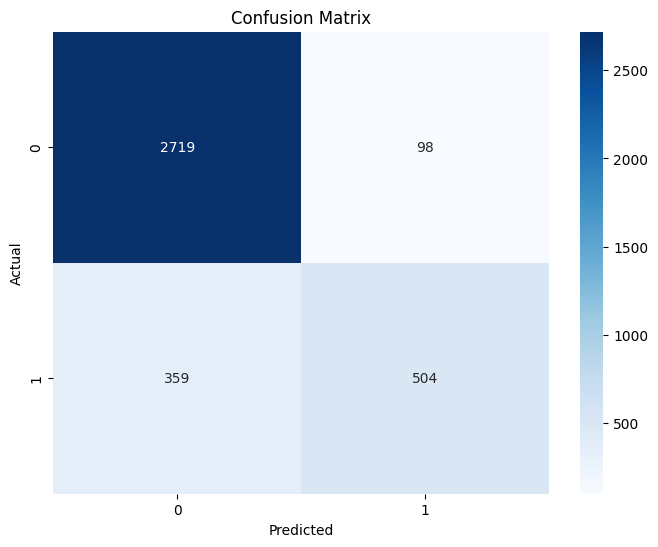

In [18]:
# 1. Print the Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Visualize the Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

adressing the imbalance by using SMOTE

In [19]:
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. Apply SMOTE only to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 3. Retrain the KNN model on the resampled data
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_resampled, y_train_resampled)

# 4. Check the new results
y_pred_new = knn_final.predict(X_test_scaled)
print("--- New Classification Report (with SMOTE) ---")
print(classification_report(y_test, y_pred_new))

--- New Classification Report (with SMOTE) ---
              precision    recall  f1-score   support

         0.0       0.91      0.82      0.86      2817
         1.0       0.55      0.74      0.63       863

    accuracy                           0.80      3680
   macro avg       0.73      0.78      0.75      3680
weighted avg       0.83      0.80      0.81      3680



In [21]:
import joblib
# Save the model and the scaler used in this version
joblib.dump(knn_final, 'loan_model_v2.pkl')
joblib.dump(scaler, 'scaler_v2.pkl')
# Save the columns so the React app knows the order
joblib.dump(X.columns.tolist(), 'model_columns_v2.pkl')

['model_columns_v2.pkl']